# El padró de Barcelona: una anàlisi demogràfica amb Python

+ **Assignatura:** Taller de Nous Usos de la Informàtica (TNUI)
+ **Durada estimada:** 4 hores
+ **Eines:** Python · pandas · matplotlib
+ **Dades:** Padró Municipal d'Habitants · Ajuntament de Barcelona (Open Data BCN)

---

## Objectius d'aprenentatge

Al final d'aquesta pràctica seràs capaç de:

1. **Carregar i explorar** fitxers CSV reals amb pandas.
2. **Identificar i gestionar** valors nuls i dades emmascades.
3. **Unir** múltiples fitxers en un únic DataFrame coherent.
4. **Transformar i agregar** dades per obtenir indicadors demogràfics.
5. **Visualitzar** tendències temporals i distribucions amb matplotlib.
6. **Comunicar** resultats amb claredat, justificant cada decisió.


> **Nota:** Les cel·les marcades amb 🔧 contenen codi que has d'escriure o completar.
> Les marcades amb ✅ ja estan resoltes i serveixen de guia.


## Com trobar ajuda sobre pandas

  Dins del notebook (la manera més ràpida):
  
  + `df.groupby?`          # docstring del mètode
  + `help(pd.merge)`       # documentació completa
  + `pd.DataFrame.<TAB>`   # autocompletat de mètodes
  
  Referència oficial:
  - Guia d'usuari (https://pandas.pydata.org/docs/user_guide/index.html) — conceptes amb exemples (filtratge, agrupació, joins…)
  - API Reference (https://pandas.pydata.org/docs/reference/index.html) — tots els mètodes, paràmetre per paràmetre

  Full de ruta ràpid:
  - Pandas Cheat Sheet (PDF) (https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf) — les operacions més habituals en una pàgina

  Quan estàs encallat:
  1. Comprova l'estat de les dades amb `df.info()`, `df.head()` i `df.dtypes`.
  2. Descriu el problema a la IA amb: quines columnes tens + quin resultat esperes.

  ---
## Com trobar ajuda sobre matplotlib

  Dins del notebook:
  + `plt.plot?`            # docstring de la funció
  + `help(plt.subplots)`   # paràmetres detallats
  
  Referència oficial:
  - Tutorials per a principiants (https://matplotlib.org/stable/tutorials/index.html) — des de la primera figura fins a subplots avançats
  - API Reference: pyplot (https://matplotlib.org/stable/api/pyplot_summary.html) — totes les funcions de plt.*
  - Galeria d'exemples (https://matplotlib.org/stable/gallery/index.html) — busca el tipus de gràfic que necessites i copia el codi

  Patrons habituals en aquesta pràctica:
  ```python
  fig, ax = plt.subplots(figsize=(10, 5))
  ax.plot(x, y, color="steelblue", label="Sèrie A")
  ax.bar(categories, valors, color="salmon")
  ax.set_title("Títol")
  ax.set_xlabel("Eix X"); ax.set_ylabel("Eix Y")
  ax.legend()
  ax.yaxis.set_major_formatter(
      plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))  # format milers
  plt.tight_layout()
  plt.savefig("grafic.png", bbox_inches="tight", dpi=150)
  ```
  
  Quan estàs encallat:
  - Matplotlib Cheat Sheets (PDF) (https://matplotlib.org/cheatsheets/) — 3 fulls: beginner, intermediate, tips & tricks
  - Cerca a la galeria pel tipus de gràfic: línia, barres, àrea apilada, scatter…


## Configuració inicial

Executa aquesta cel·la abans de començar. Importa les biblioteques necessàries i defineix les rutes de dades.

In [1]:
!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install os
!pip install glob


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement os (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for os
ERROR: Could not find a version that satisfies the requirement glob (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for glob


In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import glob
import os

# Ruta base de les dades (ajusta si cal)
BASE = "./data"
PATH_POBLACIO  = os.path.join(BASE, "poblacio_lloc_naix")
PATH_EDAT      = os.path.join(BASE, "edat_lloc_naix")
PATH_DOMICILIS = os.path.join(BASE, "domicilis_estructura")
PATH_DIMS      = os.path.join(BASE, "pad_dimensions.csv")

# Estil de gràfics
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
})

print("✓ Configuració carregada correctament")


✓ Configuració carregada correctament



## Part 1 — Exploració inicial: un sol any (2026)

Comencem carregant **un únic fitxer** per entendre l'estructura de les dades
abans d'escalar a tota la sèrie temporal.


### 1.1 ✅ Càrrega del fitxer

El dataset `poblacio_lloc_naix` conté el cens agregat per lloc de
naixement i sexe, a nivell de **secció censal**, per a cada barri i districte
de Barcelona. Hi ha **un fitxer CSV per any** (1997–2026).

> Busca la definició de secció censal.


In [3]:
# ✅ Exemple de càrrega — executeu per veure l'estructura
df_2026 = pd.read_csv(os.path.join(PATH_POBLACIO, "2026_poblacio_lloc_naix.csv"))
print("Shape:", df_2026.shape)
print()
df_2026.head(8)


Shape: (11082, 10)



,Data_Referencia,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,AEB,Seccio_Censal,Valor,LLOC_NAIX,SEXE
0,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,158,1,1
1,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,171,1,2
2,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,36,2,1
3,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,23,2,2
4,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,68,3,1
5,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,82,3,2
6,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,55,4,1
7,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,60,4,2


### 1.2 🔧 Inspecció bàsica

Respon les preguntes següents explorant el DataFrame. Escriu codi a cada cel·la.


**a) Quines columnes té el dataset i de quin tipus és cadascuna?**

In [4]:
# 🔧 Escriu el codi aquí
df_2026.dtypes

Data_Referencia      str
Codi_Districte     int64
Nom_Districte        str
Codi_Barri         int64
Nom_Barri            str
AEB                int64
Seccio_Censal      int64
Valor                str
LLOC_NAIX          int64
SEXE               int64
dtype: object

**b) Quants valors nuls hi ha per columna?**

> Busca la definició de valor nul de pandas. Tingues en compte que si hi ha valors nuls que no tenen aquets format no els detectarà com a valors nuls.

In [5]:
# 🔧 Escriu el codi aquí
df_2026.isnull().sum()

Data_Referencia    0
Codi_Districte     0
Nom_Districte      0
Codi_Barri         0
Nom_Barri          0
AEB                0
Seccio_Censal      0
Valor              0
LLOC_NAIX          0
SEXE               0
dtype: int64

**c) La columna `Valor` hauria de ser numèrica, però pot contenir el caràcter `..`
(dada emmascada per protecció de la privacitat quan el recompte és molt baix).
Quantes files contenen `..`? Quin percentatge representen?**

> Per que creus que l'ajuntament ha d'emmascarar dades?


In [6]:
# 🔧 Escriu el codi aquí
mascara = df_2026["Valor"].astype(str) == ".."
numero= mascara.sum()
porcentaje= (numero / len(df_2026)) * 100
print(porcentaje, "%"," de los datos son null")

3.717740480057751 %  de los datos son null


**d) Quants valors únics té la columna `LLOC_NAIX`?
Llista'ls. Com interpretes aquest resultat?**

> 💡 *Pista:* Consulta el fitxer `pad_dimensions.csv` per entendre els codis.


In [7]:
# 🔧 Escriu el codi aquí
numero= df_2026["LLOC_NAIX"].nunique()
print(numero, "de los datos son unicos")
print(df_2026["LLOC_NAIX"].unique())
pad= pd.read_csv(PATH_DIMS)

pad

6 de los datos son unicos
[1 2 3 4 5 6]


,Codi_Dimensio,Desc_Dimensio,Codi_Valor,Desc_Valor_CA,Desc_Valor_ES,Desc_Valor_EN
0,1,SEXE,1,Dona,Mujer,Female
1,1,SEXE,2,Home,Hombre,Male
2,2,EDAT_1,0,0 anys,0 años,0 years
3,2,EDAT_1,1,1 anys,1 años,1 years
4,2,EDAT_1,2,2 anys,2 años,2 years
...,...,...,...,...,...,...
1138,26,NACIONALITAT_DEST,142,Maurici,Mauricio,Mauritius
1139,26,NACIONALITAT_DEST,144,"Iraq, l'",Iraq,Iraq
1140,26,NACIONALITAT_DEST,145,Kenya,Kenia,Kenya
1141,26,NACIONALITAT_DEST,146,Seychelles,Seychelles,Seychelles


### 1.3 ✅ Diccionari de codis

El fitxer `pad_dimensions.csv` conté les descripcions de tots els codis
utilitzats al padró. Carrega'l i filtra els codis de la dimensió `LLOC_NAIX`.


In [8]:
# ✅ Càrrega del diccionari de dimensions
dims = pd.read_csv(PATH_DIMS)
print("Dimensions disponibles:")
print(dims[["Codi_Dimensio","Desc_Dimensio"]].drop_duplicates().to_string(index=False))


Dimensions disponibles:
 Codi_Dimensio          Desc_Dimensio
             1                   SEXE
             2                 EDAT_1
             3                 EDAT_Q
             4              LLOC_NAIX
             5         LLOC_NAIX_CCAA
             6        LLOC_NAIX_REGIO
             7         NACIONALITAT_G
             8     NACIONALITAT_REGIO
             9         NIV_EDUCA_esta
            10                 DECADA
            11         LLOC_NAIX_PAIS
            12    LLOC_NAIX_CONTINENT
            13      NACIONALITAT_PAIS
            14 NACIONALITAT_CONTINENT
            15         N_PERSONES_AGG
            16         TIPUS_DOMICILI
            17              DOM_00_18
            18              DOM_18_64
            19              DOM_65_99
            20              DOM_DONES
            21              DOM_HOMES
            22  NACIONALITAT_DOMICILI
            23          CONTINENT_MOV
            24        CODI_BARRI_DEST
            25       NACIO

In [9]:
# ✅ Codis de LLOC_NAIX (dimensió 4)
lloc_naix_dict = dims[dims["Desc_Dimensio"] == "LLOC_NAIX"][["Codi_Valor","Desc_Valor_CA"]
].rename(columns={"Codi_Valor": "LLOC_NAIX", "Desc_Valor_CA": "Lloc_Naix_Label"})
print(lloc_naix_dict.to_string(index=False))


 LLOC_NAIX          Lloc_Naix_Label
         1         Barcelona ciutat
         2       Resta de Catalunya
         3          Resta d’Espanya
         4 Resta de la Unió Europea
         5            Resta del món
         6                No consta


### 1.4 🔧 Comprensió dels codis

Ara que coneixes els codis, respon:

**a) Quants codis numèrics de `LLOC_NAIX` corresponen a categories agregades?
Quina és la interpretació de cadascun?**


In [10]:
# 🔧 Escriu el codi aquí
# 2 resta de caatalunya es grupo de todas las ciudades de cataluña quitando barcelona
#3 resta de espanya es grupo de todas las ciudades de españa quitando cataluña
# 4 resta de la unio europea es grupo de todos los paises de la union europea quitando españa
# 5 resta del mon es grupo de todos los paises del mundo quitando la union europea
#6 no consta, es un grupo q no se sabe de donde son

**b) Per a l'any 2026, calcula la **població total** de Barcelona
filtrant només els codis agregats (1–6) i sumant `Valor`.**

> ⚠️ Recorda convertir `Valor` a numèric abans de sumar
> (`pd.to_numeric(..., errors='coerce')`).


In [11]:
# 🔧 Escriu el codi aquí
df_2026["Valor"]= pd.to_numeric(df_2026["Valor"], errors="coerce")

mascara=  df_2026["LLOC_NAIX"].isin([1,2,3,4,5,6])

print(df_2026[mascara]["Valor"].sum())



1729409.0


**c) El resultat és lleugerament inferior a la xifra oficial de 1.729.963
empadronats. A quina causa ho atribueixes?
Escriu la teva hipòtesi com a comentari en el codi.**


In [12]:
# 🔧 Explica la hipòtesi aquí com a comentari Python
# ...
#puede ser por la convesion de valor a numero se pierdan ciertos datos o en el csv puedes er que no hayan datos de todo los empadronats

---
## Part 2 — Neteja i transformació

Ara que entens l'estructura, construeix un **DataFrame net i reutilitzable**
per al 2026, llest per a l'anàlisi.


### 2.1 🔧 Funció de neteja

Escriu una funció `netejar_poblacio(path)` que:

1. Llegeix el CSV des de `path`.
2. Converteix `Valor` a numèric (tractant `..` com a `NaN`).
3. Filtra **només** les files amb `LLOC_NAIX` entre 1 i 6.
4. Extreu l'any de la columna `Data_Referencia` i l'afegeixes com a nova columna `Any`.
5. Retorna el DataFrame net.

> 💡 *Pista:* `pd.to_datetime(df["Data_Referencia"]).dt.year`


In [13]:
def netejar_poblacio(path: str) -> pd.DataFrame:
    # 🔧 Implementa la funció
    ...
    daf= pd.read_csv(path)
    daf["Valor"] = pd.to_numeric(daf["Valor"], errors="coerce")

    mascara = daf["LLOC_NAIX"].isin([1, 2, 3, 4, 5, 6])
    daf = daf[mascara]
    daf["Any"] = pd.to_datetime(daf["Data_Referencia"]).dt.year
   
    return daf

# Prova la funció amb l'any 2026
df_net = netejar_poblacio(os.path.join(PATH_POBLACIO, "2026_poblacio_lloc_naix.csv"))
print("Shape net:", df_net.shape)
df_net.head()


Shape net: (11082, 11)


,Data_Referencia,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,AEB,Seccio_Censal,Valor,LLOC_NAIX,SEXE,Any
0,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,158.0,1,1,2026
1,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,171.0,1,2,2026
2,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,36.0,2,1,2026
3,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,23.0,2,2,2026
4,2026-01-01,1,Ciutat Vella,1,el Raval,1,1001,68.0,3,1,2026


### 2.2 🔧 Agregació a nivell de ciutat

El DataFrame net té dades a nivell de **secció censal**.
Agrega'l per obtenir el total de la **ciutat sencera** per a cada
combinació de `(Any, LLOC_NAIX, SEXE)`.

> Informa't sobre l'operador `groupby` de pandas i fes-lo servir.


In [14]:
# 🔧 Agrega per Any, LLOC_NAIX i SEXE
df_ciutat = df_net.groupby(["Any", "LLOC_NAIX", "SEXE"],as_index=False)["Valor"].sum()

# Verifica: hauries de tenir 12 files (6 llocs × 2 sexes)
print("Files:", len(df_ciutat))
df_ciutat


Files: 12


,Any,LLOC_NAIX,SEXE,Valor
0,2026,1,1,394793.0
1,2026,1,2,376703.0
2,2026,2,1,62495.0
3,2026,2,2,54312.0
4,2026,3,1,124666.0
5,2026,3,2,89546.0
6,2026,4,1,42325.0
7,2026,4,2,42079.0
8,2026,5,1,273421.0
9,2026,5,2,269064.0


### 2.3 🔧 Unió amb el diccionari

Uneix `df_ciutat` amb `lloc_naix_dict` per afegir l'etiqueta
descriptiva a cada codi `LLOC_NAIX`.

> Informa't sobre l'operador `merge` de pandas i fes-lo servir.



In [15]:
# 🔧 Escriu el codi aquí
df_ciutat2 = pd.merge(df_ciutat, lloc_naix_dict, on=["LLOC_NAIX"], how="left")

print(df_ciutat2)


     Any  LLOC_NAIX  SEXE     Valor           Lloc_Naix_Label
0   2026          1     1  394793.0          Barcelona ciutat
1   2026          1     2  376703.0          Barcelona ciutat
2   2026          2     1   62495.0        Resta de Catalunya
3   2026          2     2   54312.0        Resta de Catalunya
4   2026          3     1  124666.0           Resta d’Espanya
5   2026          3     2   89546.0           Resta d’Espanya
6   2026          4     1   42325.0  Resta de la Unió Europea
7   2026          4     2   42079.0  Resta de la Unió Europea
8   2026          5     1  273421.0             Resta del món
9   2026          5     2  269064.0             Resta del món
10  2026          6     1       5.0                 No consta
11  2026          6     2       0.0                 No consta


### 2.4 🔧 Taula resum

Crea una taula pivot que mostri, per a 2026, la **població per lloc de
naixement** (files) i **sexe** (columnes), amb el total com a fila final.

> 💡 *Pista:* `pd.pivot_table(...)`

> Una taula pivot és una eina d’anàlisi de dades que permet resumir i reorganitzar la informació d’una taula original per facilitar-ne la interpretació. En aquest cas, la taula pivot ha de mostrar la població de l’any 2026 agrupada per lloc de naixement a les files i per sexe a les columnes, calculant el nombre total de persones per a cada combinació. A més, ha d’incloure una fila final amb els totals generals, de manera que es pugui comparar fàcilment la distribució de la població segons aquestes dues variables.


In [16]:
# 🔧 Escriu el codi aquí
df_ciutat3= pd.pivot_table(df_ciutat2, index=["Lloc_Naix_Label"], columns=["SEXE"], values="Valor",aggfunc="sum",margins=True)
print(df_ciutat3)

SEXE                             1         2        All
Lloc_Naix_Label                                        
Barcelona ciutat          394793.0  376703.0   771496.0
No consta                      5.0       0.0        5.0
Resta de Catalunya         62495.0   54312.0   116807.0
Resta de la Unió Europea   42325.0   42079.0    84404.0
Resta del món             273421.0  269064.0   542485.0
Resta d’Espanya           124666.0   89546.0   214212.0
All                       897705.0  831704.0  1729409.0


### 2.5 🔧 Reflexió: qualitat de les dades

Escriu com a text (cel·la Markdown) una breu reflexió (3-5 frases) sobre:
- Quines decisions de neteja has pres i per què.
- Quin impacte tenen els valors `..` en l'anàlisi.
- Quin risc hi ha d'introduir biaixos si s'ignoren sense documentar.


Tener que limpiar datos que no son completos, filas enteras,

Tienen de impacto que básicamente se pierden datos que pueden servirnos para analizar pero filtrarlos sirven para poder representarlos sin que haya errores 

Que puede provocar una representación errónea de la realidad (mas de lo q ya conlleva) si esos datos concretos sirven para representar un sector. Si nos aclara que faltan datos, puede provocar que la gente crea o interprete algo erróneo a partir del erróneo de los datos que hemos analizado.

*🔧 Escriu la teva reflexió aquí.*


---
## Part 3 — Sèrie temporal 1997–2026

Ara escala la teva funció de neteja als **30 fitxers** disponibles
per construir la sèrie temporal completa.


### 3.1 🔧 Càrrega de tots els anys

Usa `glob.glob()` per obtenir la llista de fitxers i aplica
`netejar_poblacio()` a cadascun. Concatena els resultats en un
únic DataFrame `df_serie`.


In [ ]:
fitxers = sorted(glob.glob(os.path.join(PATH_POBLACIO, "*.csv")))
print(f"Fitxers trobats: {len(fitxers)}")

# 🔧 Carrega tots els anys i concatena
for i in range(len(fitxers)):
    if i == 0:
        df_serie = netejar_poblacio(fitxers[i])
    else:
        df_serie = pd.concat([df_serie, netejar_poblacio(fitxers[i])], ignore_index=True)
print("Shape total:", df_serie.shape)
print("Anys disponibles:", sorted(df_serie["Any"].unique()))


Fitxers trobats: 30
Shape total: (328341, 11)
Anys disponibles: [np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


### 3.2 🔧 Consistència entre anys

Abans de continuar, **verifica la consistència** del dataset combinat:

**a)** Hi ha algun any amb un nombre de files significativament diferent
de la resta? Quina podria ser la causa?


In [24]:
# 🔧 Escriu el codi aquí
filas= df_serie["Any"].value_counts().sort_index()
print(filas)

Any
1997    10695
1998    10716
1999    10746
2000    10784
2001    10829
2002    10886
2003    10945
2004    10988
2005    11027
2006    11061
2007    11045
2008    11040
2009    10924
2010    10866
2011    10884
2012    10891
2013    10895
2014    10901
2015    10926
2016    10931
2017    10948
2018    10953
2019    11000
2020    11071
2021    11073
2022    11017
2023    11053
2024    11082
2025    11082
2026    11082
Name: count, dtype: int64


**b)** Per a cada any (1997-2026), calcula la **població total** (suma de tots els
codis 1–6, tots dos sexes). Representa'la com a gràfic de línies.


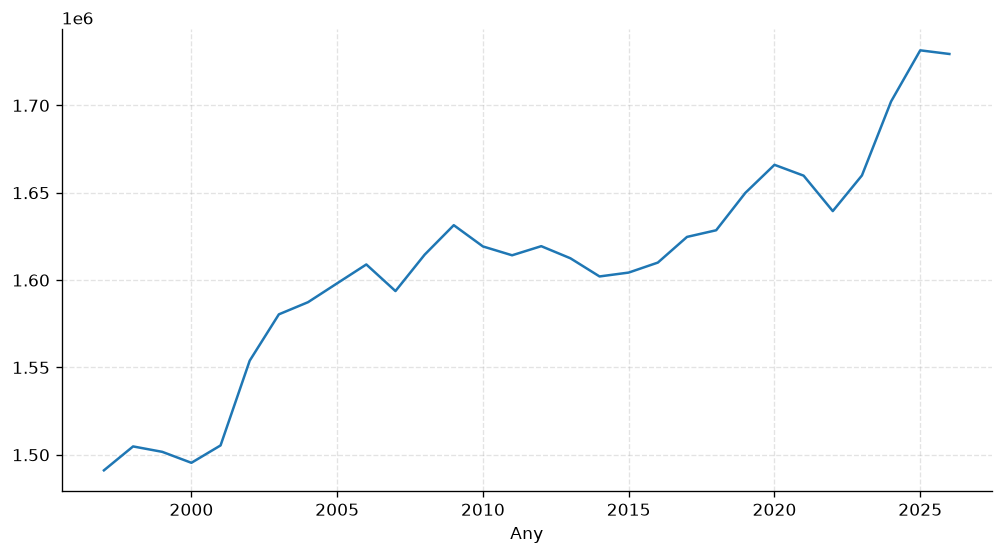

In [32]:
# 🔧 Escriu el codi aquí

# sumar todos los cosigos y sexes es basicamente el año entero
df6 = df_serie.groupby("Any")["Valor"].sum()


plt.figure(figsize=(10, 5))
df6.plot(kind="line")

plt.grid(True)

plt.show()

### 3.3 🔧 Agregació per lloc de naixement

Per a la visualització principal, necessites la **suma total** (ambdós
sexes) de cada `LLOC_NAIX` per any.

Per resoldre l’exercici, es recomana utilitzar un encadenament d’operacions de Pandas (method chaining) similar al següent exemple:

```python
serie_lloc = (
    df_serie
    .groupby(["Any", "LLOC_NAIX"], as_index=False)["Valor"]
    .sum()
    .rename(columns={"Valor": "Total"})
)
```

Aquest estil de programació permet expressar de manera clara i concisa les diferents transformacions aplicades al conjunt de dades. En aquest exercici, es demana construir la taula pivot mitjançant un encadenament d’instruccions similar, combinant operacions com ara el filtratge de l’any 2026, la creació de la taula pivot, el càlcul de totals i el canvi de noms de columnes quan sigui necessari. L’objectiu és que el codi sigui llegible, fàcil de mantenir i coherent amb les bones pràctiques habituals en anàlisi de dades amb Pandas.

Crea un DataFrame `serie_lloc` amb columnes: `Any`, `LLOC_NAIX`,
`Lloc_Naix_Label`, `Total`.


In [39]:
# 🔧 Escriu el codi aquí
serie_lloc = (
    df_serie
    .groupby(["Any", "LLOC_NAIX"],as_index=False)["Valor"]
    .sum()
    .rename(columns={"Valor": "Total"})
    .merge(lloc_naix_dict, on="LLOC_NAIX", how="left")
)
print(serie_lloc)

      Any  LLOC_NAIX     Total           Lloc_Naix_Label
0    1997          1  887263.0          Barcelona ciutat
1    1997          2  128207.0        Resta de Catalunya
2    1997          3  424754.0           Resta d’Espanya
3    1997          4   12840.0  Resta de la Unió Europea
4    1997          5   38046.0             Resta del món
..    ...        ...       ...                       ...
175  2026          2  116807.0        Resta de Catalunya
176  2026          3  214212.0           Resta d’Espanya
177  2026          4   84404.0  Resta de la Unió Europea
178  2026          5  542485.0             Resta del món
179  2026          6       5.0                 No consta

[180 rows x 4 columns]


### 3.4 🔧 Visualització: sèrie temporal

Fés un gràfic amb quatre línies (BCN, Resta Catalunya, Resta Espanya, Resta del món)
des del 1997 fins al 2026.

Requisits del gràfic:
- Títol i etiquetes dels eixos en català.
- Llegenda clara.
- Etiqueta amb el valor final de cada línia (2026) a la dreta.
- Paleta de colors coherent.
- Una anotació que marqui algun moment clau que pot haver tingut impacgte en la població (ex: crisi 2008, pandèmia 2020).

> 💡 Per al grup "Resta del món", agrupa els codis 4, 5 i 6.


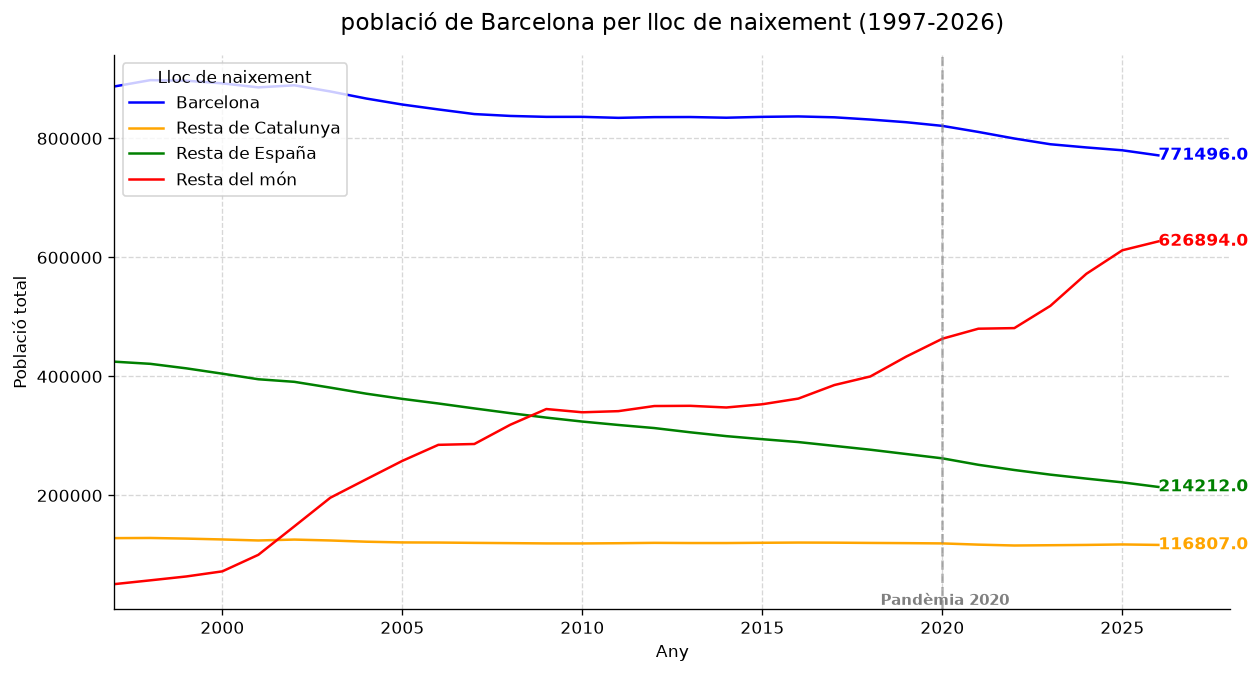

In [67]:
# 🔧 Escriu el codi aquí

# Recorda: plt.savefig('grafic_serie.png', bbox_inches='tight')
plt.figure(figsize=(12, 6))

#mascaras pa separarlos
bcn= serie_lloc["LLOC_NAIX"] == 1
cat= serie_lloc["LLOC_NAIX"] == 2
españa= serie_lloc["LLOC_NAIX"] == 3
mundo= serie_lloc["LLOC_NAIX"].isin([4,5,6])

#años
abcn=serie_lloc[bcn].groupby("Any")["Total"].sum()
acat=serie_lloc[cat].groupby("Any")["Total"].sum()
aespaña=serie_lloc[españa].groupby("Any")["Total"].sum()
amundo=serie_lloc[mundo].groupby("Any")["Total"].sum()

plt.plot(abcn, label="Barcelona",color="blue")
plt.plot(acat, label="Resta de Catalunya",color="orange")
plt.plot(aespaña, label="Resta de España",color="green")
plt.plot(amundo, label="Resta del món",color="red")

plt.text(2026, abcn.loc[2026], f"{abcn.loc[2026]}",color="blue", fontweight="bold", va="center")
plt.text(2026, acat.loc[2026], f"{acat.loc[2026]}", color="orange", fontweight="bold", va="center")
plt.text(2026, aespaña.loc[2026], f"{aespaña.loc[2026]}", color="green", fontweight="bold", va="center")
plt.text(2026, amundo.loc[2026], f"{amundo.loc[2026]}", color="red", fontweight="bold", va="center")

plt.axvline(x=2020, color="gray", linestyle="--", alpha=0.6)
plt.text(
    2020, 
    10000, 
    " Pandèmia 2020", 
    color="gray", 
    fontweight="bold", 
    fontsize=9, 
    va="bottom", 
    ha="center"
)

plt.title("població de Barcelona per lloc de naixement (1997-2026)", fontsize=14, pad=15)
plt.xlabel("Any")
plt.ylabel("Població total")
plt.legend(title="Lloc de naixement", loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(1997, 2028)

plt.savefig("grafic_serie.png", bbox_inches="tight")
plt.show()

---
## Part 4 — Estructura dels domicilis (2026)

Canviem de dataset: ara analitzem com es distribueixen els
**684.077 domicilis** de Barcelona per tipus d'estructura familiar.


### 4.1 🔧 Càrrega i exploració

Carrega `2026_domicilis_estructura.csv`.
Fes una inspecció equivalent a la de la Part 1:
shape, dtypes, nuls, valors únics de `TIPUS_DOMICILI`.


In [ ]:
# 🔧 Escriu el codi aquí


### 4.2 ✅ Diccionari de TIPUS_DOMICILI


In [ ]:
# ✅ Codis de TIPUS_DOMICILI (dimensió 16)
tipus_dict = dims[dims["Desc_Dimensio"] == "TIPUS_DOMICILI"][
    ["Codi_Valor","Desc_Valor_CA"]
].rename(columns={"Codi_Valor": "TIPUS_DOMICILI",
                   "Desc_Valor_CA": "Tipus_Label"})
print(tipus_dict.to_string(index=False))


### 4.3 🔧 Agregació i unió

Calcula el **nombre total de domicilis** per a cada codi `TIPUS_DOMICILI`
a nivell de tota la ciutat. Uneix amb `tipus_dict` per tenir l'etiqueta.
Ordena per nombre de domicilis de major a menor.


In [ ]:
# 🔧 Escriu el codi aquí


### 4.4 🔧 Visualització: estructura dels domicilis

Crea un **gràfic de barres horitzontals** que mostri els 12 tipus
de domicili, amb:
- Etiquetes descriptives (del diccionari) a l'eix Y.
- Percentatge sobre el total al costat de cada barra.
- Colors que diferenciïn les llars unipersonals, les de dos, les de tres o més
  i les que inclouen menors.


In [ ]:
# 🔧 Escriu el codi aquí


### 4.5 🔧 Indicadors clau

Calcula i imprimeix:

a) Nombre i percentatge de domicilis on viu **una única persona**.
b) Nombre i percentatge de domicilis amb **presència de menors** (codis 9–12).
c) Comparació entre **dones soles ≥ 65 anys** i **homes sols ≥ 65 anys**.
   Quina és la ràtio? Quin fenomen sociodemogràfic reflecteix?


In [ ]:
# 🔧 Escriu el codi aquí


---
## Part 5 — Edat mitjana per lloc de naixement (2026)

Fins ara hem analitzat *quants* residents hi ha de cada origen.
Ara ens preguntem: *quina edat mitjana* té cada grup?
Aquesta informació és clau per entendre els fluxos migratoris
i les necessitats de serveis socials.


### 5.1 ✅ Estructura del dataset d'edat quinquennal

El fitxer `2026_edat_lloc_naix.csv` conté la població desagregada per
**grups d'edat quinquennals** (`EDAT_Q`), lloc de naixement i sexe.


In [ ]:
# ✅ Carrega el dataset d'edat
df_edat = pd.read_csv(os.path.join(PATH_EDAT, "2026_edat_lloc_naix.csv"))
df_edat["Valor"] = pd.to_numeric(df_edat["Valor"], errors="coerce")
print("Shape:", df_edat.shape)
df_edat.head()


### 5.2 ✅ Diccionari de grups d'edat quinquennals


In [ ]:
# ✅ Codis EDAT_Q (dimensió 3)
edat_q_dict = dims[dims["Desc_Dimensio"] == "EDAT_Q"][
    ["Codi_Valor","Desc_Valor_CA"]
].rename(columns={"Codi_Valor":"EDAT_Q","Desc_Valor_CA":"Edat_Label"})
print(edat_q_dict.to_string(index=False))


### 5.3 🔧 Punt mig de cada grup

Per calcular l'edat mitjana ponderada necessitem assignar un
**punt mig** a cada grup quinquennal.

Completa el diccionari `MIDPOINTS` seguint la lògica:
- Grup 0 (<5 anys) → 2 anys
- Grup 1 (5-9 anys) → 7 anys
- …
- Grup 20 (≥100 anys) → 100 anys
- Grup 21 (No consta) → `None` (s'ha d'excloure del càlcul)


In [19]:
# 🔧 Completa el diccionari de punts mig
MIDPOINTS = {i: ___  for i in range(20)}   # grups 0–19
MIDPOINTS[20] = ___   # ≥ 100 anys
MIDPOINTS[21] = None  # No consta → s'exclou

# Comprova que tens 21 valors numèrics (grup 21 és None)
assert sum(1 for v in MIDPOINTS.values() if v is not None) == 21
print("✓ MIDPOINTS correcte")


✓ MIDPOINTS correcte


### 5.4 🔧 Càlcul de l'edat mitjana ponderada

L'**edat mitjana ponderada** de cada grup es calcula com:

$$\bar{E} = \frac{\sum_i \text{midpoint}_i \cdot \text{poblaci\'o}_i}{\sum_i \text{poblaci\'o}_i}$$

Implementa la funció `edat_mitjana_per_lloc(df, midpoints)` que:
1. Afegeixi una columna `midpoint` a partir de `EDAT_Q`.
2. Exclogui les files amb `EDAT_Q == 21` (No consta).
3. Calculi l'edat mitjana per a cada codi `LLOC_NAIX` (1–6).
4. Retorni un DataFrame amb columnes `LLOC_NAIX` i `Edat_Mitjana`.

> 💡 Pista: `groupby(...).apply(lambda g: ...)`


In [18]:
def edat_mitjana_per_lloc(df: pd.DataFrame, midpoints: dict) -> pd.DataFrame:
    # 🔧 Implementa la funció
    ...

edat_m = edat_mitjana_per_lloc(df_edat, MIDPOINTS)
edat_m = edat_m.merge(lloc_naix_dict, on="LLOC_NAIX")
print(edat_m.to_string(index=False))


NameError: name 'df_edat' is not defined

### 5.5 🔧 Visualització i interpretació

**a)** Crea un gràfic de barres verticals que mostri l'edat mitjana
de cada grup de lloc de naixement, amb:
- Colors coherents amb els del gràfic de sèrie temporal.
- El valor numèric a sobre de cada barra.
- Una línia horitzontal discontínua que marqui l'edat mitjana global de la ciutat.

> 💡 Edat mitjana global estimada: calcula-la tu mateix a partir del dataset.


In [ ]:
# 🔧 Gràfic d'edat mitjana
# Recorda: plt.savefig('grafic_edat_mitjana.png', bbox_inches='tight')


**b)** Interpreta el resultat:

- La diferència d'edat entre el grup nascut a la Resta d'Espanya i els
  nascuts a la Resta del Món és d'uns 27 anys. A quin fenomen històric
  es deu?
- Si la immigració estrangera cessa completament a partir del 2026,
  quin efecte esperes en l'edat mitjana global d'aquí a 20 anys?
  Argumenta qualitativament sense necessitat de fer projeccions numèriques.

*🔧 Escriu la teva resposta aquí.*


*🔧 Escriu la teva resposta aquí.*


---
## Part 6 — Síntesi i comunicació

L'últim pas en qualsevol projecte de ciència de dades és
**comunicar els resultats** de forma clara i rigorosa.


### 6.1 🔧 Informe breu (Markdown)

Escriu, en aquesta mateixa cel·la Markdown, un informe d'entre
**300 i 500 paraules** que respongui les preguntes:

1. Quina és la tendència principal de la composició de la població
   barcelonina entre el 1997 i el 2026?
2. Quines implicacions té l'envelliment dels residents nascuts a la
   resta d'Espanya per als serveis socials de la ciutat?
3. Quin model de convivència predomina avui a Barcelona?
   Ha canviat respecte a dècades anteriors?
4. Quina limitació important té aquest dataset per respondre
   preguntes causals? (Per exemple: per què marxen les famílies?)

*🔧 Escriu el teu informe aquí.*


### 6.2 🔧 El millor gràfic

Tria **un sol gràfic** de tots els que has creat que consideres
el més informatiu o el que millor il·lustra la història de les dades.
Afina'l: títol clar, subtítol explicatiu, etiquetes, llegenda, font.

Justifica (3-4 frases) per què l'has triat per sobre dels altres.


In [ ]:
# 🔧 El teu millor gràfic, polít i complet


### 6.3 🔧 Una pregunta oberta

Proposa **una pregunta** que les dades disponibles NO poden respondre
però que seria rellevant per entendre millor la demografia de Barcelona.
Indica quin dataset addicional caldria per respondre-la.

*🔧 Escriu la teva pregunta aquí.*
